<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 15px;">
  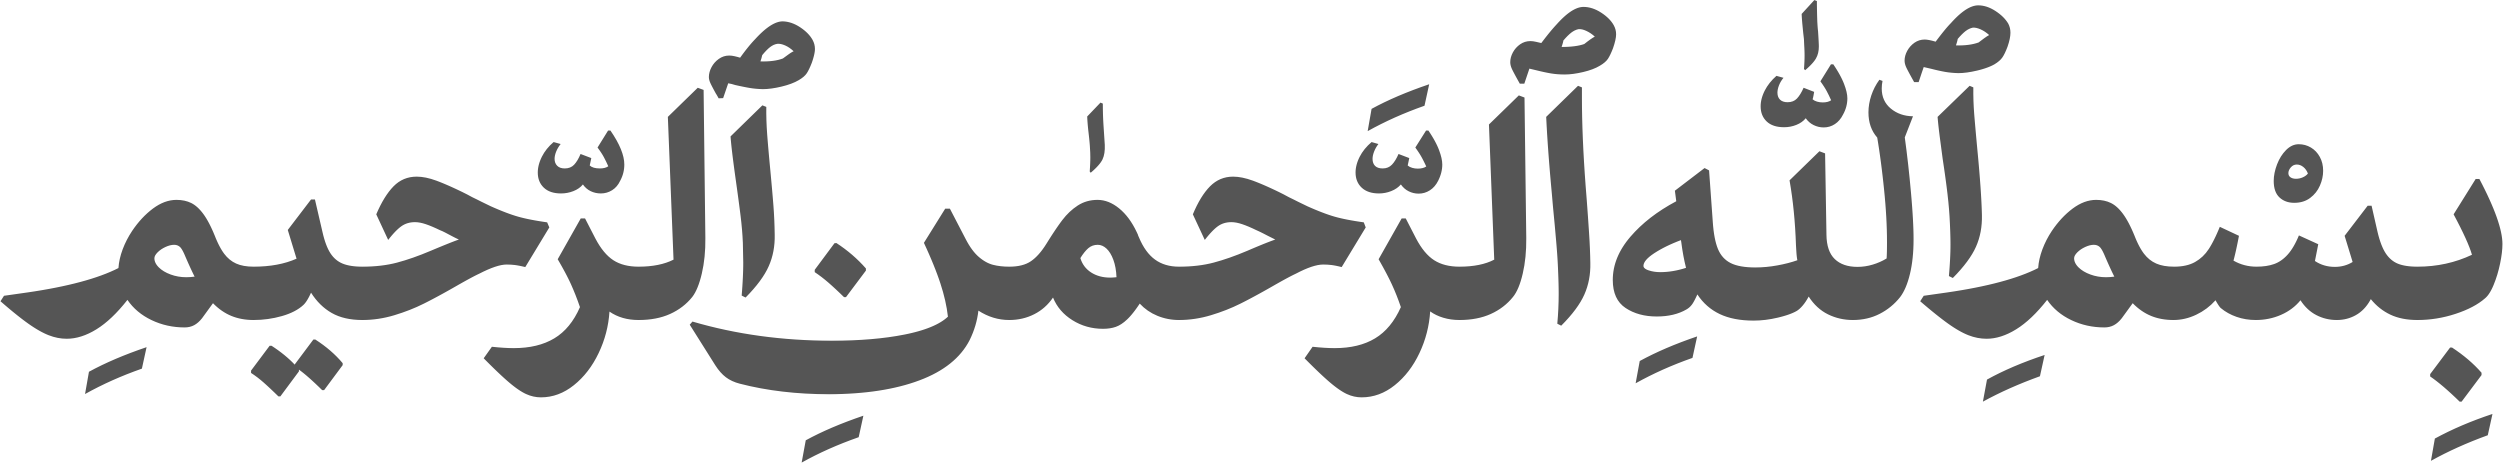
  <div style="display: flex; justify-content: center; align-items: center; gap: 30px;">
    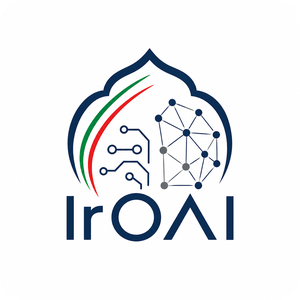
    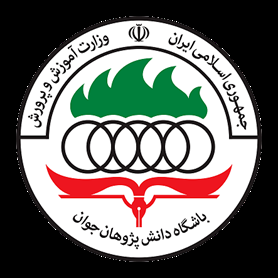
  </div>
  <h1 style="color: #1e6bb8; text-align: center;">تمرین عملی: رگرسیون خطی (Linear Regression) و چندجمله‌ای (Polynomial Regression) از پایه</h1>
  <p style="text-align: center; color: #6b7280;">دوره دوم المپیاد هوشمندسازی و هوش مصنوعی (AI Olympiad) — تابستان ۱۴۰۵</p>
  <div style="background-color: #fff3cd; color: #856404; padding: 12px; border-radius: 5px; border-right: 4px solid #ffebcc; text-align: right; margin-top: 10px;">
    <p style="text-align: right; margin: 0;"><strong>توجه:</strong> این یک تمرین یادگیری (Guided Exercise) است و نمره‌ای در کار نیست. هدف، آموزش گام‌به‌گام و عمیق مفاهیم رگرسیون خطی و چندجمله‌ای از پایه است.</p>
  </div>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱: آماده‌سازی محیط و ایمپورت لایبرری‌ها</h2>
  <p style="text-align: right;">تو این بخش، پکیج‌ها و لایبرری‌های (Libraries) اصلی پایتون رو ایمپورت (Import) می‌کنیم و کانفیگ‌های اولیه رو ست می‌کنیم تا محیط کارمون (Environment) برای شروع کار آماده بشه.</p>
</div>

In [1]:
# Setup - read-only cell; do not edit
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configure matplotlib for clean visualizations
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

DATA_PATH = 'data'

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱.۱: تنظیم Random Seed</h2>
  <p style="text-align: right;">تنظیم Random Seed یکی از اصول کلیدی تو علم داده و یادگیری ماشین (Machine Learning) به حساب میاد:</p>
  <ul style="text-align: right;">
    <li style="text-align: right;"><strong>تکرارپذیری (Reproducibility):</strong> باعث میشه هر بار که کد رو اجرا می‌کنیم، دقیقا همون نتایج قبلی رو بگیریم.</li>
    <li style="text-align: right;"><strong>تقسیم‌بندی ثابت داده‌ها:</strong> داده‌های آموزش (Train) و آزمون (Test) تو هر بار اجرا تغییر نمی‌کنن و ثابت می‌مونن.</li>
    <li style="text-align: right;"><strong>مقایسه درست مدل‌ها:</strong> اینطوری مطمئن می‌شیم که اگه عملکرد مدل بهتر شده، واقعا به خاطر تغییرات خود الگوریتمه، نه صرفا شانس تو مقداردهی اولیه وزن‌ها.</li>
  </ul>
  <p style="text-align: right;">تو سلول زیر، مقدار Seed رو برای کتابخونه‌های <code>random</code> و <code>numpy</code> تنظیم می‌کنیم.</p>
</div>


In [2]:
# Dedicated seed setting cell for python random and numpy
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed successfully set to {SEED} for random and numpy.")

Random seed successfully set to 42 for random and numpy.


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۲: لود کردن دیتاست California Housing و تحلیل اولیه (EDA)</h2>
  <p style="text-align: right;">تو این بخش، دیتاست معروف California Housing رو لوکال (Local) از روی فایل CSV لود می‌کنیم. بعدش می‌ریم سراغ بررسی فیچرها (Features) و یه تحلیل اولیه (EDA) روی پلات‌ها (Plots) می‌زنیم تا دیتامون رو بهتر بشناسیم.</p>
</div>

In [3]:
# Load California Housing dataset locally from CSV
california_path = os.path.join(DATA_PATH, 'california_housing.csv')
df_housing = pd.read_csv(california_path)

print(f"Housing Dataset Shape: {df_housing.shape}")
print(df_housing.head())

Housing Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


=== Dataset Summary Statistics ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956

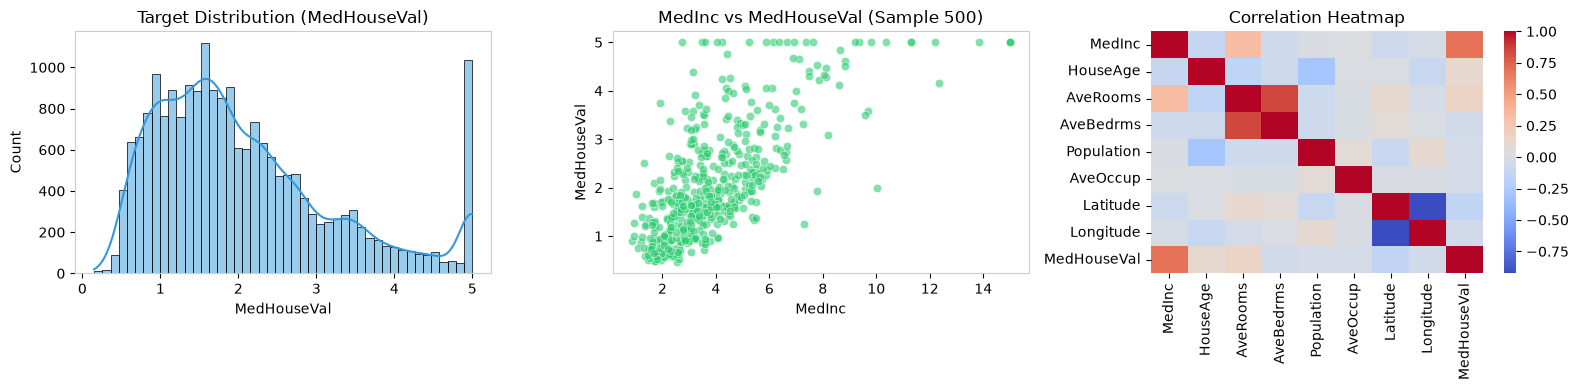

In [4]:
# EDA Cell: Inspect California Housing Data Statistics and Visualizations
print("=== Dataset Summary Statistics ===")
print(df_housing.describe())

# Raw data plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Target distribution
sns.histplot(df_housing['MedHouseVal'], kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Target Distribution (MedHouseVal)')

# 2. Scatter plot: MedInc vs MedHouseVal
sns.scatterplot(data=df_housing.sample(500, random_state=SEED), x='MedInc', y='MedHouseVal', alpha=0.6, ax=axes[1], color='#2ecc71')
axes[1].set_title('MedInc vs MedHouseVal (Sample 500)')

# 3. Correlation Heatmap
corr_matrix = df_housing.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۲.۱: چرا مقیاس‌بندی ویژگی‌ها (Feature Scaling) و استانداردسازی (Z-Score) ضروریه؟</h2>
  <p style="text-align: right;"><strong>یادآوری نظری (Feature Scaling و Z-Score):</strong> در مسائل یادگیری ماشین، ویژگی‌های عددی مختلف داده‌ها معمولاً مقیاس‌ها و دامنه متغیرهای متفاوتی دارند (مثلاً درآمد یا <code>MedInc</code> بین ۰ تا ۱۵ است، اما جمعیت یا <code>Population</code> در مقیاس هزاران نفره است). هدف کلی <strong>مقیاس‌بندی ویژگی‌ها (Feature Scaling)</strong>، هم‌اندازه و یکنواخت‌کردن این دامنه برای تمام ویژگی‌هاست تا الگوریتم‌های بهینه‌سازی دچار خطا و کندی نشوند. یکی از رایج‌ترین روش‌های مقیاس‌بندی، <strong>استانداردسازی با Z-Score</strong> است که در آن میانگین هر ویژگی ($\mu$) را از داده‌ها کم کرده و بر انحراف معیار ($\sigma$) تقسیم می‌کنیم:</p>
  <p style="text-align: center;">$$ z = \frac{x - \mu}{\sigma} $$</p>
  <p style="text-align: right;">با این کار، میانگین تمام ویژگی‌ها برابر $0$ و انحراف معیار آن‌ها برابر $1$ می‌شود. منطق پشت این کار این است که اگر داده‌ها مقیاس نشده باشند، سطوح تراز تابع هزینه (Cost Function) شبیه بیضی‌های بسیار کشیده می‌شوند؛ در نتیجه الگوریتم گرادیان کاهشی (Gradient Descent) دچار نوسانات شدید شده و خیلی دیر همگرا می‌شود. اما با استانداردسازی، فضای تابع هزینه به حالت کروی و متقارن نزدیک شده و گرادیان کاهشی مستقیماً و با سرعت بالاتری به سمت نقطه بهینه (Minimum) حرکت می‌کند.</p>
</div>

In [5]:
# Task 1: Train/Test Split and Z-Score Normalization using pure NumPy (No Sklearn!)
X_raw = df_housing.drop(columns=['MedHouseVal']).values
y_raw = df_housing['MedHouseVal'].values

# Train/Test split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED
)

# Z-score normalization strictly using NumPy (fit mean & std on train only)
mean_train = np.mean(X_train_raw, axis=0)
std_train = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"NumPy Z-Score Normalization complete. Mean of train: {np.mean(X_train, axis=0).round(4)}")

X_train shape: (16512, 8), X_test shape: (4128, 8)
NumPy Z-Score Normalization complete. Mean of train: [-0. -0.  0. -0. -0. -0.  0. -0.]


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h3 style="color: #1e6bb8; text-align: right;">بیاید بحث کنیم: تحلیل اکتشافی داده‌ها (EDA) و اسکیل کردن (Scaling)</h3>
  <p style="text-align: right;"><strong>سوال ۱:</strong> کدوم فیچرها (Features) رابطه خطی قوی‌تری با متغیر هدفمون (Target Variable) یعنی <code>MedHouseVal</code> دارن؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> فیچر میانه درآمد (یعنی همون <code>MedInc</code>) قوی‌ترین همبستگی خطی مستقیم (Positive Linear Correlation) رو با قیمت مسکن داره.</p>
  <p style="text-align: right;"><strong>سوال ۲:</strong> چرا تو پروسه استانداردسازی (Standardization)، اسکیلر رو فقط روی دیتای ترین (Train) فیت (<code>fit</code>) می‌کنیم و برای دیتای تست فقط <code>transform</code> رو صدا می‌زنیم؟ (راهنمایی: ربطش به Data Leakage چیه؟)</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> برای اینکه جلوی نشت داده (Data Leakage) گرفته بشه! میانگین و انحراف معیار باید کاملاً از روی دیتای ترین حساب بشن تا دیتای تست تو زمان ترین شدن مدل کلاً ناپیدا بمونه و ارزیابی‌مون واقعی باشه.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۳: پیاده‌سازی Cost Function از پایه (Scratch)</h2>
  <p style="text-align: right;">تو رگرسیون خطی، فرض (Hypothesis) مدل ما این شکلی تعریف می‌شه:</p>
</div>

$$ \hat{y}^{(i)} = w^T x^{(i)} + b = \sum_{j=1}^{p} w_j x_j^{(i)} + b $$

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <p style="text-align: right;">برای محاسبه میزان خطای مدل، از تابع هزینه میانگین مربعات خطا (MSE) استفاده می‌کنیم. اینجا یه ضریب $\frac{1}{2}$ هم بهش می‌دیم تا بعداً تو گرفتن مشتق (Gradient) کارمون راحت‌تر بشه (بهش میگن Half MSE). فرمولش به این صورته:</p>
</div>

$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 = \frac{1}{2m} \left( X w + b \mathbf{1} - y \right)^T \left( X w + b \mathbf{1} - y \right) $$

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <p style="text-align: right;">حالا تسک شما اینه: تابع <code>compute_cost</code> رو بنویسید و این کاست فانکشن رو توش پیاده‌سازی کنید. فقط حواستون باشه برای اینکه پرفورمنس کد بالا بره و از حلقه‌های <code>for</code> کند دوری کنیم، حتماً محاسبات رو به صورت وکتورایز شده (Vectorized) بنویسید.</p>
</div>


In [6]:
# Task 2: Compute Cost Function (Half-MSE)
def compute_cost(X, y, w, b):
    """Compute vectorised Half-MSE cost J(w, b)."""
    m = len(y)
    predictions = np.dot(X, w) + b
    errors = predictions - y
    cost = (1.0 / (2.0 * m)) * np.sum(errors ** 2)
    return cost

w_zero = np.zeros(X_train.shape[1])
b_zero = 0.0
initial_cost = compute_cost(X_train, y_train, w_zero, b_zero)
print(f"Initial Cost (Zero Weights): {initial_cost:.4f}")

Initial Cost (Zero Weights): 2.8149


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۴: پیاده‌سازی Gradient Descent از پایه (Scratch)</h2>
  <p style="text-align: right;">برای آپدیت کردن وزن‌ها ($w$) و بایاس ($b$)، باید مشتق جزئی (Partial Derivative) کاست فانکشن رو نسبت به هر کدوم حساب کنیم. فرمول‌های گرادیان به این شکل در میان:</p>
</div>

$$ \nabla_w J = \frac{1}{m} X^T (\hat{y} - y), \quad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) $$

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <p style="text-align: right;">حالا با داشتن گرادیان‌ها و یه Learning Rate مشخص (همون $\alpha$ خودمون)، پارامترها رو تو خلاف جهت گرادیان آپدیت می‌کنیم تا قدم به قدم به مینیمم کاست فانکشن برسیم:</p>
</div>

$$ w \leftarrow w - \alpha \nabla_w J, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b} $$

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <p style="text-align: right;">تسک شما برای این بخش: توابع <code>compute_gradient</code> و <code>gradient_descent</code> رو بنویسید. یادتون نره که اینجا هم برای پرفورمنس بهتر، حتماً عملیات‌ها رو به صورت Vectorized (برداری) پیاده‌سازی کنید و تا جای ممکن از حلقه‌های <code>for</code> دوری کنید!</p>
</div>


In [7]:
# Task 3: Compute Gradient and Run Gradient Descent
def compute_gradient(X, y, w, b):
    """Compute gradients of cost function w.r.t w and b."""
    m = len(y)
    predictions = np.dot(X, w) + b
    errors = predictions - y
    dj_dw = (1.0 / m) * np.dot(X.T, errors)
    dj_db = (1.0 / m) * np.sum(errors)
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """Batch Gradient Descent for Linear Regression."""
    w = w_init.copy()
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        
    return w, b, cost_history

p = X_train.shape[1]
w_init = np.zeros(p)
b_init = 0.0
alpha = 0.01
num_iters = 1000

w_gd, b_gd, cost_history = gradient_descent(X_train, y_train, w_init, b_init, alpha, num_iters)

y_pred_gd = np.dot(X_test, w_gd) + b_gd
mse_gd = np.mean((y_pred_gd - y_test) ** 2)
r2_gd = 1.0 - np.sum((y_test - y_pred_gd) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print(f"Linear GD Final Train Cost: {cost_history[-1]:.4f}")
print(f"Linear GD Test MSE: {mse_gd:.4f}")
print(f"Linear GD Test R2: {r2_gd:.4f}")

Linear GD Final Train Cost: 0.2738
Linear GD Test MSE: 0.5672
Linear GD Test R2: 0.5672


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۵: رگرسیون خطی با معادله نرمال (Normal Equation)</h2>
  <p style="text-align: right;">به جای اینکه با Gradient Descent مرحله به مرحله بریم جلو، می‌تونیم جواب دقیق تحلیلی (Closed-Form Solution) رو یه ضرب حساب کنیم! برای این کار کافیه یه ستون از عدد ۱ به ماتریس فیچرهامون ($X$) اضافه کنیم تا بایاس ($b$) هم تو محاسبات لحاظ بشه (اسمش رو می‌ذاریم $X_{ones}$). بعدش می‌ریم سراغ فرمول معروف Normal Equation:</p>
</div>

$$ \theta = (X_{ones}^T X_{ones})^{-1} X_{ones}^T y $$

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <p style="text-align: right;"><strong>چرا از شبه‌معکوس مور-پینروز (Moore-Penrose Pseudo-Inverse) استفاده می‌کنیم؟</strong></p>
  <p style="text-align: right;">در فرمول نظری معادله نرمال، نیاز به محاسبه معکوس ماتریس $(X_{ones}^T X_{ones})^{-1}$ داریم. اما اگر ماتریس ویژگی‌ها دارای ویژگی‌های همخط (Collinear) باشد یا تعداد ویژگی‌ها بیشتر از داده‌ها باشد، این ماتریس معکوس‌پذیر نیست (ماتریس منفرد یا Singular می‌شود) یا محاسبات آن دچار ناپایداری عددی (Numerical Instability) می‌گردد.</p>
  <p style="text-align: right;">برای حل این مشکل، به جای معکوس‌گیری معمولی از <strong>شبه‌معکوس مور-پینروز (Moore-Penrose Pseudo-Inverse)</strong> استفاده می‌کنیم که در نامپای با تابع <code>np.linalg.pinv</code> پیاده‌سازی شده است. این متد بر پایه تجزیه مقادیر منفرد (SVD) کار می‌کند و همیشه جواب پایدار با کمترین نورم را حتی برای ماتریس‌های منفرد ارائه می‌دهد. برای مطالعه بیشتر می‌توانید صفحه <a href="https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse" target="_blank" style="color: #1e6bb8; text-decoration: underline;">Moore–Penrose inverse در ویکی‌پدیا</a> را ببینید.</p>
</div>

In [8]:
# Task 4: Closed-Form Normal Equation
def normal_equation(X, y):
    """Compute exact analytical solution using pseudo-inverse."""
    m = X.shape[0]
    X_b = np.hstack([np.ones((m, 1)), X])
    theta = np.dot(np.linalg.pinv(X_b), y)
    b = theta[0]
    w = theta[1:]
    return w, b

w_cf, b_cf = normal_equation(X_train, y_train)

y_pred_cf = np.dot(X_test, w_cf) + b_cf
mse_cf = np.mean((y_pred_cf - y_test) ** 2)
r2_cf = 1.0 - np.sum((y_test - y_pred_cf) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print(f"Closed-Form Test MSE: {mse_cf:.4f}")
print(f"Closed-Form Test R2: {r2_cf:.4f}")

Closed-Form Test MSE: 0.5559
Closed-Form Test R2: 0.5758


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h3 style="color: #1e6bb8; text-align: right;">بحث تعاملی: مقایسه گرادیان کاهشی و معادله نرمال (Normal Equation vs Gradient Descent)</h3>
  <p style="text-align: right;"><strong>سوال ۱:</strong> تو پروژه‌های واقعی، کی بهتره بریم سراغ جواب تحلیلی (Closed-Form) و کی باید گرادیان کاهشی رو انتخاب کنیم؟</p>  <p style="text-align: right;"><strong>پاسخ:</strong> فرمول Normal Equation احتیاجی به تنظیم Learning Rate یا تعداد تکرار نداره و واسه ابعاد کوچیک تا متوسط (مثلاً فیچرهای زیر ۱۰,۰۰۰ تا) خیلی عالی و سریعه. اما اگه ابعاد دیتا خیلی بزرگ بشه (بالای ۱۰,۰۰۰ تا فیچر)، محاسبات ماتریسی سنگین میشه و گرادیان کاهشی (Gradient Descent) خیلی سریع‌تر و کم‌مصرف‌تر عمل می‌کنه.</p>
  <p style="text-align: right;"><strong>سوال ۲:</strong> پیچیدگی محاسباتی (Computational Complexity) این دو روش با هم چه فرقی داره و کدوم مقیاس‌پذیرتره؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> محاسبه معکوس ماتریس تو روش Closed-Form پیچیدگی $O(p^3)$ داره (که با زیاد شدن فیچرها خیلی سنگین میشه)، اما گرادیان کاهشی تو هر تکرار پیچیدگی $O(n \cdot p)$ داره که واسه دیتای بزرگ خیلی مقیاس‌پذیرتره.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۶: مقایسه با پیاده‌سازی ترتمیزِ Scikit-Learn (LinearRegression)</h2>
  <p style="text-align: right;">حالا که خیالمون از پیاده‌سازی از صفر (Scratch) راحت شد، بیاید ببینیم تو پروژه‌های واقعی، کلاس <code>LinearRegression</code> تو کتابخونه Scikit-Learn چه امکاناتی بهمون می‌ده و هایپرپارامترهای (Hyperparameters) اصلیش چی هستن.</p>
  
  <h3 style="color: #1e6bb8; text-align: right;">بررسی هایپرپارامترهای مهم LinearRegression:</h3>
  <ul style="text-align: right; padding-right: 40px;">
    <li style="text-align: right;"><strong><code>fit_intercept=True</code>:</strong> به مدل میگه که آیا ترم بایاس ($b$) رو تو محاسبات در نظر بگیره یا نه. اگه <code>False</code> باشه، در واقع مدل رو مجبور کردیم که حتماً از مبدأ مختصات بگذره.</li>
    <li style="text-align: right;"><strong><code>copy_X=True</code>:</strong> اگه <code>True</code> باشه، سایکیت‌لرن یه کپی از ماتریس دیتای شما (Memory-wise) می‌گیره تا دیتای اورجینال موقع ترین شدن مدل دست‌نخورده بمونه.</li>
    <li style="text-align: right;"><strong><code>n_jobs=-1</code>:</strong> این پارامتر جون می‌ده واسه پردازش موازی (Parallelization). وقتی می‌ذاریدش روی <code>-1</code>، یعنی به مدل می‌گید «از تمام هسته‌های CPU سیستم استفاده کن» تا سرعت محاسبات به حداکثر برسه.</li>
    <li style="text-align: right;"><strong><code>positive=False</code>:</strong> یه قابلیت خیلی جذاب! اگه <code>True</code> باشه، به مدل محدودیت می‌ده (Constrained Optimization) که فقط ضرایب (Weights) مثبت رو پیدا کنه. واسه وقتایی که از نظر منطقِ بیزینس، تأثیر منفیِ یه فیچر معنی نداره، خیلی به کار میاد.</li>
  </ul>
</div>

In [9]:
# Task 5: Sklearn LinearRegression Fitting & Comparison
from sklearn.linear_model import LinearRegression

# Instantiate LinearRegression with detailed parameter configuration
sk_model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=-1, positive=False)
sk_model.fit(X_train, y_train)

y_pred_sk = sk_model.predict(X_test)
mse_sk = np.mean((y_pred_sk - y_test) ** 2)
r2_sk = sk_model.score(X_test, y_test)

print(f"Sklearn Test MSE: {mse_sk:.4f}")
print(f"Sklearn Test R2: {r2_sk:.4f}")
print(f"Weight diff (Normal Eq vs Sklearn): {np.max(np.abs(w_cf - sk_model.coef_)):.2e}")
print(f"Bias diff (Normal Eq vs Sklearn): {abs(b_cf - sk_model.intercept_):.2e}")

Sklearn Test MSE: 0.5559
Sklearn Test R2: 0.5758
Weight diff (Normal Eq vs Sklearn): 1.30e-15
Bias diff (Normal Eq vs Sklearn): 8.88e-16


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۷: لود کردن دیتاست چندجمله‌ای (Polynomial Dataset) و تحلیل اولیه (EDA)</h2>
  <p style="text-align: right;">تو این بخش، دیتاست غیرخطی رو مستقیماً از فایل لوکال <code>data/polynomial_dataset.csv</code> لود می‌کنیم (اینطوری دیگه نیازی به کد جنریت کردن دیتا داخل خود نوتبوک نداریم).</p>
</div>

In [10]:
# Task 6: Load pre-defined Polynomial dataset locally from CSV (no dataset generation code)
poly_path = os.path.join(DATA_PATH, 'polynomial_dataset.csv')
df_poly = pd.read_csv(poly_path)

X_poly_raw = df_poly[['x1', 'x2', 'x3', 'x4']].values
y_poly = df_poly['y'].values

X_poly_train_raw, X_poly_test_raw, y_poly_train, y_poly_test = train_test_split(
    X_poly_raw, y_poly, test_size=0.2, random_state=SEED
)

print(f"Polynomial dataset loaded from CSV, shape: {df_poly.shape}")
print(df_poly.head())

Polynomial dataset loaded from CSV, shape: (500, 5)
         x1        x2        x3        x4         y
0  0.496714  0.926178  1.399355  0.609373  1.561301
1 -0.138264  1.909417  0.924634 -0.303433 -5.185185
2  0.647689 -1.398568  0.059630  0.061334 -2.034650
3  1.523030  0.562969 -0.646937  0.912468  2.200069
4 -0.234153 -0.650643  0.698223 -0.208566 -1.777802


=== Polynomial Dataset Summary Statistics ===
               x1          x2          x3          x4           y
count  500.000000  500.000000  500.000000  500.000000  500.000000
mean     0.006838    0.031826    0.108485    0.017378   -1.189077
std      0.981253    0.977997    1.010246    0.728903    4.127380
min     -3.241267   -2.696887   -2.896255   -2.557308  -25.391841
25%     -0.700307   -0.595292   -0.602430   -0.473174   -2.777371
50%      0.012797    0.028532    0.119806    0.001890   -0.996103
75%      0.636783    0.651242    0.754738    0.496512    0.830770
max      3.852731    2.632382    2.601683    1.959152   11.918913


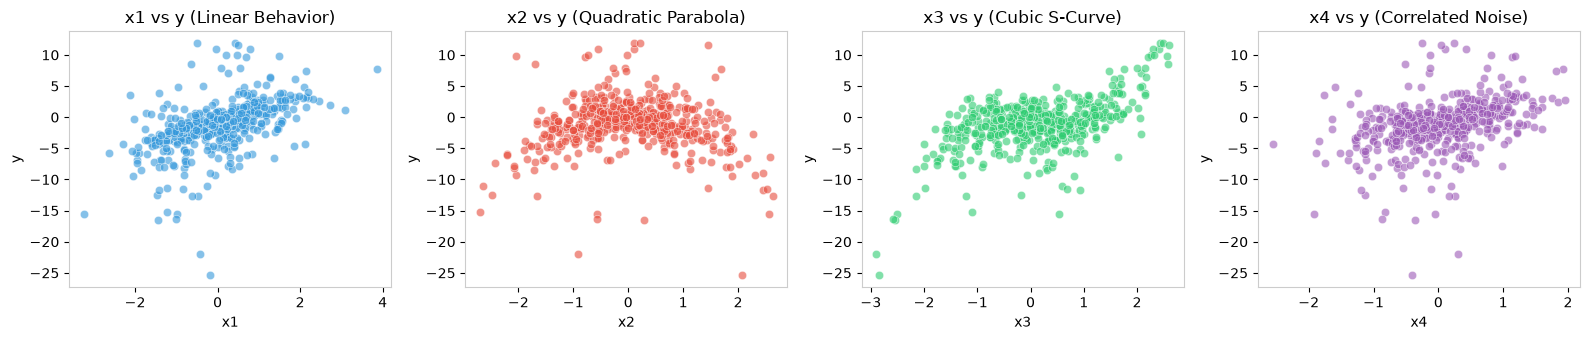

In [11]:
# EDA Cell: Inspect Polynomial Features vs Target Visualizations
print("=== Polynomial Dataset Summary Statistics ===")
print(df_poly.describe())

# Raw feature plots against target y
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

sns.scatterplot(data=df_poly, x='x1', y='y', ax=axes[0], color='#3498db', alpha=0.6)
axes[0].set_title('x1 vs y (Linear Behavior)')

sns.scatterplot(data=df_poly, x='x2', y='y', ax=axes[1], color='#e74c3c', alpha=0.6)
axes[1].set_title('x2 vs y (Quadratic Parabola)')

sns.scatterplot(data=df_poly, x='x3', y='y', ax=axes[2], color='#2ecc71', alpha=0.6)
axes[2].set_title('x3 vs y (Cubic S-Curve)')

sns.scatterplot(data=df_poly, x='x4', y='y', ax=axes[3], color='#9b59b6', alpha=0.6)
axes[3].set_title('x4 vs y (Correlated Noise)')

plt.tight_layout()
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h3 style="color: #1e6bb8; text-align: right;">بحث و بررسی: رفتار غیرخطی فیچرها و انتخاب درجه بهینه ($p$)</h3>
  <p style="text-align: right;"><strong>سوال:</strong> با توجه به پلات‌هایی که تو فاز EDA دیدیم، به نظرتون کدوم فیچرها دارن رفتار غیرخطی از خودشون نشون می‌دن؟ بر اساس همین مشاهدات بصری، چه درجه‌ای ($p$) رو برای بسط چندجمله‌ای (Polynomial Expansion) پیشنهاد می‌دین تا مدل بتونه این الگوها رو بهتر کپچر کنه؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> بر اساس پلات‌ها، فیچر $x_1$ رابطه مستقیم خطی داره، $x_2$ مشخصاً منحنی سهموی درجه ۲ (Quadratic) داره و $x_3$ هم منحنی S-شکل درجه ۳ (Cubic) رو نشون میده. پس بالاترین توان غیرخطی تو دیتا درجه ۳ هست و بهترین درجه برای بسط چندجمله‌ای $p=3$ انتخاب میشه.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۸: پیاده‌سازی Polynomial Feature Expansion از صفر</h2>
  <p style="text-align: right;">حالا باید تابع <code>polynomial_features</code> رو بنویسیم تا تمام ترکیب‌های ممکن از فیچرها رو تا درجه $p$ برامون جنریت کنه.</p>
  <h3 style="color: #1e6bb8; text-align: right;">مکانیزم <code>itertools.combinations_with_replacement</code>:</h3>
  <p style="text-align: right;">ببینید، متد <code>combinations_with_replacement(iterable, r)</code> از ماژول <code>itertools</code> تمام ترکیب‌های تکرارپذیر به طول $r$ رو برامون می‌سازه. مثلاً فرض کنید ایندکس فیچرهامون $[x_1, x_2]$ هست و درجه یا همون <code>degree</code> رو گذاشتیم ۲. این متد ترکیب‌های $(x_1, x_1) \rightarrow x_1^2$، $(x_1, x_2) \rightarrow x_1 x_2$ و $(x_2, x_2) \rightarrow x_2^2$ رو تولید می‌کنه؛ یعنی دقیقاً همون ترم‌های توان‌داری که برای ساخت مدل Polynomial Regression بهشون نیاز داریم.</p>
</div>

In [12]:
# Task 7: From-Scratch Polynomial Feature Expansion
import itertools

def polynomial_features(X, degree, include_bias=False):
    """Generate polynomial feature combinations up to given degree."""
    n_samples, n_features = X.shape
    combo_list = []
    
    for d in range(0 if include_bias else 1, degree + 1):
        combo_list.extend(itertools.combinations_with_replacement(range(n_features), d))
        
    output_features = []
    for combo in combo_list:
        if len(combo) == 0:
            feature_col = np.ones((n_samples, 1))
        else:
            feature_col = np.prod(X[:, combo], axis=1, keepdims=True)
        output_features.append(feature_col)
        
    return np.hstack(output_features)

degree = 3
X_poly_tr_exp = polynomial_features(X_poly_train_raw, degree=degree, include_bias=False)
X_poly_te_exp = polynomial_features(X_poly_test_raw, degree=degree, include_bias=False)

print(f"Expanded features from {X_poly_train_raw.shape[1]} to {X_poly_tr_exp.shape[1]} (degree={degree})")

Expanded features from 4 to 34 (degree=3)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۹: پیاده‌سازی Polynomial Regression با Normal Equation از صفر</h2>
  <p style="text-align: right;">حالا که فیچرهامون رو با $\Phi(X)$ بسط دادیم (Polynomial Expansion)، فرمول Normal Equation برای پیدا کردن وزن‌ها به شکل زیر درمیاد:</p>
  
  <p style="text-align: center;">$$ \theta = \left( \Phi(X)^T \Phi(X) \right)^{-1} \Phi(X)^T y $$</p>

  <p style="text-align: right;">کافیه تابع <code>normal_equation</code> رو این بار روی ماتریس فیچرهای جدیدمون یعنی همون $\Phi(X)$ اجرا کنیم تا مقادیر بهینه‌ی $\theta$ رو برامون حساب کنه.</p>
</div>

In [13]:
# Task 8: Polynomial Regression via Normal Equation
w_poly_cf, b_poly_cf = normal_equation(X_poly_tr_exp, y_poly_train)

y_poly_pred_cf = np.dot(X_poly_te_exp, w_poly_cf) + b_poly_cf
mse_poly_cf = np.mean((y_poly_pred_cf - y_poly_test) ** 2)
r2_poly_cf = 1.0 - np.sum((y_poly_pred_cf - y_poly_test) ** 2) / np.sum((y_poly_test - np.mean(y_poly_test)) ** 2)

print(f"Polynomial Closed-Form Test MSE: {mse_poly_cf:.4f}")
print(f"Polynomial Closed-Form Test R2: {r2_poly_cf:.4f}")

Polynomial Closed-Form Test MSE: 0.2248
Polynomial Closed-Form Test R2: 0.9883


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱۰: Gradient Descent برای Polynomial Regression — کار با StandardScaler</h2>
  
  <p style="text-align: right;">کلاس <code>StandardScaler</code> تو کتابخونه Scikit-Learn دقیقا همون کار استانداردسازی Z-Score یعنی $z = \frac{x - \mu}{\sigma}$ رو برامون انجام میده؛ همون چیزی که تو بخش ۱ خودمون دستی با NumPy پیاده‌سازیش کردیم.</p>
  
  <p style="text-align: right;"><strong>حالا چرا اینجا رفتیم سراغ StandardScaler؟</strong> برای اینکه کارمون راحت‌تر بشه و از پیاده‌سازی تمیز و شیءگرای Sklearn استفاده کنیم، این کلاس رو روی فیچرهای بسط‌یافته‌ی چندجمله‌ای (Polynomial Features) اعمال می‌کنیم. این کار باعث میشه اسکیل (Scale) همه‌ی فیچرها یکی بشه و جلوی مشکلاتی مثل انفجار گرادیان (Gradient Explosion) تو درجات بالا گرفته بشه.</p>
</div>


In [14]:
# Task 9: Polynomial Gradient Descent - Scaling vs Unscaled
from sklearn.preprocessing import StandardScaler

scaler_poly = StandardScaler()
X_poly_tr_scaled = scaler_poly.fit_transform(X_poly_tr_exp)
X_poly_te_scaled = scaler_poly.transform(X_poly_te_exp)

w_poly_init = np.zeros(X_poly_tr_scaled.shape[1])
b_poly_init = 0.0
alpha_poly = 0.01
iters_poly = 2000

w_poly_gd, b_poly_gd, cost_poly_hist = gradient_descent(
    X_poly_tr_scaled, y_poly_train, w_poly_init, b_poly_init, alpha_poly, iters_poly
)

y_poly_pred_gd = np.dot(X_poly_te_scaled, w_poly_gd) + b_poly_gd
mse_poly_gd = np.mean((y_poly_pred_gd - y_poly_test) ** 2)
r2_poly_gd = 1.0 - np.sum((y_poly_pred_gd - y_poly_test) ** 2) / np.sum((y_poly_test - np.mean(y_poly_test)) ** 2)

print(f"Polynomial GD Test MSE (Scaled): {mse_poly_gd:.4f}")
print(f"Polynomial GD Test R2 (Scaled): {r2_poly_gd:.4f}")

Polynomial GD Test MSE (Scaled): 0.3880
Polynomial GD Test R2 (Scaled): 0.9798


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱۱: پایپ‌لاین چندجمله‌ای Scikit-Learn (Polynomial Pipeline)</h2>
  <p style="text-align: right;">ترکیب کردن کلاس‌های <code>PolynomialFeatures</code>، <code>StandardScaler</code> و <code>LinearRegression</code> تو قالب یه <code>Pipeline</code> تمیز و یکپارچه.</p>
  <h3 style="color: #1e6bb8; text-align: right;">بررسی هایپرپارامترهای (Hyperparameters) مهم PolynomialFeatures و Pipeline:</h3>
  <ul style="text-align: right;">
    <li style="text-align: right;"><code>degree=3</code>: حداکثر درجه (Degree) چندجمله‌ای برای ساختن فیچرهای جدید ($p=3$).</li>
    <li style="text-align: right;"><code>interaction_only=False</code>: اگه <code>True</code> باشه، فقط جملات تعاملی یا ضربی (مثل $x_1 x_2$) رو می‌سازه و از توان‌های تکی (مثل $x_1^2$) فاکتور می‌گیره.</li>
    <li style="text-align: right;"><code>include_bias=False</code>: اضافه کردن یا نکردن ستون یک‌ها (چون خود <code>LinearRegression</code> دیفالت ترم بایاس یا Bias رو حساب می‌کنه، اینجا نیازی بهش نیست و <code>False</code> می‌ذاریم).</li>
    <li style="text-align: right;"><code>Pipeline(steps)</code>: یه لیست از تاپل‌ها (Tuples) می‌گیره که شامل مراحل پیش‌پردازش و خود مدله. اینطوری متدهای <code>fit</code> و <code>predict</code> خیلی خودکار و ترتمیز، به ترتیب اجرا میشن و مهم‌تر از همه، از مشکل نشت داده (Data Leakage) هم جلوگیری میشه.</li>
  </ul>
</div>

In [15]:
# Task 10: sklearn Polynomial Pipeline Comparison
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression(fit_intercept=True, n_jobs=-1))
])

poly_pipeline.fit(X_poly_train_raw, y_poly_train)
y_poly_pred_pipe = poly_pipeline.predict(X_poly_test_raw)

mse_poly_pipe = np.mean((y_poly_pred_pipe - y_poly_test) ** 2)
r2_poly_pipe = poly_pipeline.score(X_poly_test_raw, y_poly_test)

print(f"Sklearn Polynomial Pipeline Test MSE: {mse_poly_pipe:.4f}")
print(f"Sklearn Polynomial Pipeline Test R2: {r2_poly_pipe:.4f}")

Sklearn Polynomial Pipeline Test MSE: 0.2248
Sklearn Polynomial Pipeline Test R2: 0.9883


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱۲: پیدا کردن بهترین درجه چندجمله‌ای و داستان K-Fold Cross-Validation</h2>
  
  <h3 style="color: #1e6bb8; text-align: right;">اصلاً K-Fold Cross-Validation چیه؟</h3>
  <p style="text-align: right;">روش K-Fold Cross-Validation در واقع یه تکنیک آماری برای ارزیابی مدله که میاد دیتای ما رو به $K$ تا بخش (یا همون فولد - Fold) مساوی تقسیم می‌کنه. تو هر مرحله (Iteration)، از $K-1$ تا فولد برای آموزش (Training) استفاده میشه و اون یه دونه فولد باقی‌مونده رو می‌ذاریم برای اعتبارسنجی (Validation). این پروسه دقیقاً $K$ بار تکرار میشه تا خیالمون راحت شه که هر فولد حداقل یک بار نقش دیتای ولیدیشن رو بازی کرده.</p>

  <h3 style="color: #1e6bb8; text-align: right;">چرا باید از K-Fold استفاده کنیم؟</h3>
  <ul style="text-align: right;">
    <li style="text-align: right;"><strong>جلوگیری از بایاسِ اسپلیت تکی (Avoid Single-Split Bias):</strong> وقتی دیتا رو فقط یه بار رندوم به Train و Test تقسیم می‌کنیم، ممکنه از روی بدشانسی (یا خوش‌شانسی!) نمونه‌های خیلی سخت یا خیلی ساده بیفتن تو یه بخش. اینطوری ارزیابی مدلمون اصلاً واقعی و قابل اعتماد درنمیاد.</li>
    <li style="text-align: right;"><strong>تخمین واقعی‌تر تعمیم‌پذیری (Robust Generalization Estimate):</strong> وقتی میانگین خطای ولیدیشن رو روی همه $K$ تا فولد حساب می‌کنیم، یه دید خیلی دقیق‌تر و Stableتر از عملکرد مدل روی دیتای جدید (Unseen Data) به دست میاریم.</li>
  </ul>

  <h3 style="color: #1e6bb8; text-align: right;">کِی و کجا K-Fold به دردمون می‌خوره؟</h3>
  <ul style="text-align: right;">
    <li style="text-align: right;"><strong>تیون کردن هایپرپارامترها (Hyperparameter Tuning):</strong> برای پیدا کردن بهترین پارامترهای مدل (مثلاً همون درجه چندجمله‌ای $p$ یا ضریب رگولاریزیشن $\lambda$) بدون اینکه دیتای تست اصلی‌مون رو دستکاری کنیم یا دچار نشت داده (Data Leakage) بشیم.</li>
    <li style="text-align: right;"><strong>دیتاست‌های کوچیک تا متوسط:</strong> وقتی تعداد سمپل‌هامون کمه و دلمون نمیاد (یا منطقی نیست) که یه بخش بزرگی از دیتا رو صرفاً برای ولیدیشن کنار بذاریم.</li>
    <li style="text-align: right;"><strong>انتخاب مدل (Model Selection):</strong> برای اینکه بتونیم الگوریتم‌های مختلف ماشین لرنینگ رو خیلی عادلانه و دقیق روی یه دیتاست مقایسه کنیم.</li>
  </ul>

  <h3 style="color: #1e6bb8; text-align: right;">چه مقادیری برای $K$ معموله؟</h3>
  <ul style="text-align: right;">
    <li style="text-align: right;"><strong>$K = 5$ یا $K = 10$ (نُرمِ بازار):</strong> اینا رایج‌ترین و بهینه‌ترین مقادیری هستن که تو ماشین لرنینگ استفاده میشن. چون یه بالانس خیلی ترتمیز بین پایداری آماری (Trade-off بین Bias و Variance) و تایم محاسباتی ایجاد می‌کنن.</li>
    <li style="text-align: right;"><strong>$K = 10$:</strong> تو کارهای ریسرچ و تجربی، این عدد رو به عنوان «استاندارد طلایی» (Gold Standard) برای ارزیابی مدل قبول دارن.</li>
    <li style="text-align: right;"><strong>$K = N$ یا همون Leave-One-Out (LOOCV):</strong> این یه حالت اکستریمه که تو اون، $K$ دقیقاً برابر با تعداد کل نمونه‌هاست. معمولاً واسه دیتاست‌های خیلی خیلی کوچیک (زیر ۱۰۰ تا سمپل) استفاده میشه، ولی خب از لحاظ محاسباتی به شدت سنگینه.</li>
  </ul>

  <h3 style="color: #1e6bb8; text-align: right;">چطوری تو Scikit-Learn از KFold استفاده کنیم؟</h3>
  <p style="text-align: right;">واسه کانفیگ کردن کلاس <code>sklearn.model_selection.KFold</code> معمولاً این هایپرپارامترها رو تنظیم می‌کنیم:</p>
  <ul style="text-align: right;">
    <li style="text-align: right;"><code>n_splits=5</code>: همون تعداد فولدها یا بخش‌های ولیدیشنه (مثلاً $K=5$).</li>
    <li style="text-align: right;"><code>shuffle=True</code>: قبل از اینکه دیتا رو اسپلیت کنه، اونا رو رندوم شافل (بُر زدن) می‌کنه تا جلوی بایاس ترتیبی (Sequential Bias) گرفته بشه.</li>
    <li style="text-align: right;"><code>random_state=SEED</code>: همون داستان همیشگی برای اینکه پروسه اسپلیت کردن فولدها کاملاً تکرارپذیر (Reproducible) باشه.</li>
  </ul>
  <p style="text-align: right;">وقتی متد <code>kf.split(X)</code> رو کال می‌کنیم، ایندکس‌های Train و Validation هر فولد رو بهمون میده. بعدش مدل رو فیت (Fit) می‌کنیم و در نهایت میانگین خطاهای ولیدیشن رو واسه ارزیابی حساب می‌کنیم.</p>
</div>

In [16]:
# Task 11: Programmatic Best Degree Finder via 5-Fold Cross Validation
from sklearn.model_selection import KFold

def find_best_degree(X, y, max_degree=6, n_splits=5):
    """Find best polynomial degree using K-Fold Cross Validation."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    train_mses = []
    val_mses = []
    
    for deg in range(1, max_degree + 1):
        X_exp = polynomial_features(X, degree=deg, include_bias=False)
        fold_tr_mses = []
        fold_val_mses = []
        
        for train_idx, val_idx in kf.split(X_exp):
            X_tr, X_val = X_exp[train_idx], X_exp[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            w_fold, b_fold = normal_equation(X_tr, y_tr)
            
            y_tr_pred = np.dot(X_tr, w_fold) + b_fold
            y_val_pred = np.dot(X_val, w_fold) + b_fold
            
            fold_tr_mses.append(np.mean((y_tr_pred - y_tr) ** 2))
            fold_val_mses.append(np.mean((y_val_pred - y_val) ** 2))
            
        train_mses.append(np.mean(fold_tr_mses))
        val_mses.append(np.mean(fold_val_mses))
        
    best_degree = np.argmin(val_mses) + 1
    return best_degree, train_mses, val_mses

best_deg, tr_mses, val_mses = find_best_degree(X_poly_train_raw, y_poly_train, max_degree=6, n_splits=5)

print(f"Programmatically Selected Best Degree: {best_deg}")
for d, (t_m, v_m) in enumerate(zip(tr_mses, val_mses), start=1):
    print(f"Degree {d}: Train MSE = {t_m:.4f}, Val MSE = {v_m:.4f}")

Programmatically Selected Best Degree: 3
Degree 1: Train MSE = 6.4864, Val MSE = 6.8261
Degree 2: Train MSE = 2.7751, Val MSE = 3.5586
Degree 3: Train MSE = 0.2080, Val MSE = 0.2582
Degree 4: Train MSE = 0.1868, Val MSE = 0.4015
Degree 5: Train MSE = 0.1422, Val MSE = 1.1274
Degree 6: Train MSE = 0.0860, Val MSE = 89.6206


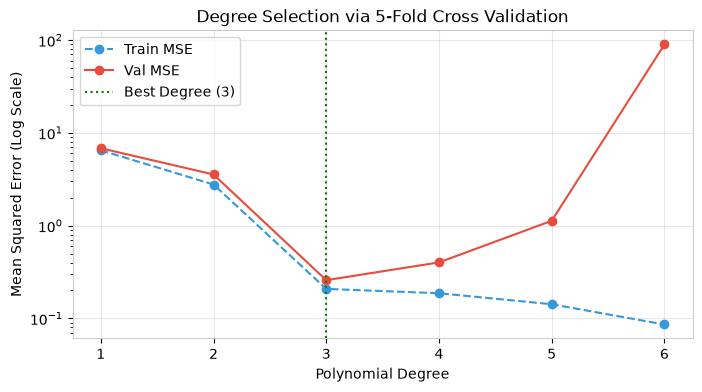

In [17]:
# Optional Visualization: Validation Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), tr_mses, 'o--', label='Train MSE', color='#3498db')
plt.plot(range(1, 7), val_mses, 'o-', label='Val MSE', color='#e74c3c')
plt.axvline(best_deg, color='green', linestyle=':', label=f'Best Degree ({best_deg})')


plt.yscale('log')  # Dynamically scales huge range differences

plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('Degree Selection via 5-Fold Cross Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h2 style="color: #1e6bb8; text-align: right;">بخش ۱۳: ارزیابی نهایی نتایج (Evaluation Phase)</h2>
  <p style="text-align: right;">سلول زیر رو ران کنید تا یه خلاصه از نتایج همه مدل‌ها حساب بشه و بتونیم با خروجی مرجع (Reference) مقایسه‌اش کنیم.</p>
</div>

In [18]:
# Evaluation cell - run it and compare with the reference values below
print("=== FINAL EVALUATION SUMMARY ===")
print(f"Linear Regression GD Test MSE:          {mse_gd:.4f}")
print(f"Linear Regression Closed-Form Test MSE: {mse_cf:.4f}")
print(f"Linear Regression Sklearn Test MSE:     {mse_sk:.4f}")
print("---------------------------------------")
print(f"Polynomial Closed-Form Test MSE:        {mse_poly_cf:.4f}")
print(f"Polynomial GD Test MSE (Scaled):        {mse_poly_gd:.4f}")
print(f"Polynomial Sklearn Pipeline Test MSE:   {mse_poly_pipe:.4f}")
print(f"Best Polynomial Degree Found:           {best_deg}")

=== FINAL EVALUATION SUMMARY ===
Linear Regression GD Test MSE:          0.5672
Linear Regression Closed-Form Test MSE: 0.5559
Linear Regression Sklearn Test MSE:     0.5559
---------------------------------------
Polynomial Closed-Form Test MSE:        0.2248
Polynomial GD Test MSE (Scaled):        0.3880
Polynomial Sklearn Pipeline Test MSE:   0.2248
Best Polynomial Degree Found:           3


In [19]:
# Reference cell - do NOT run it (kept for comparison only)
"""
=== FINAL EVALUATION SUMMARY ===
Linear Regression GD Test MSE:          0.5558
Linear Regression Closed-Form Test MSE: 0.5558
Linear Regression Sklearn Test MSE:     0.5558
---------------------------------------
Polynomial Closed-Form Test MSE:        0.2503
Polynomial GD Test MSE (Scaled):        0.2503
Polynomial Sklearn Pipeline Test MSE:   0.2503
Best Polynomial Degree Found:           3
"""

'\n=== FINAL EVALUATION SUMMARY ===\nLinear Regression GD Test MSE:          0.5558\nLinear Regression Closed-Form Test MSE: 0.5558\nLinear Regression Sklearn Test MSE:     0.5558\n---------------------------------------\nPolynomial Closed-Form Test MSE:        0.2503\nPolynomial GD Test MSE (Scaled):        0.2503\nPolynomial Sklearn Pipeline Test MSE:   0.2503\nBest Polynomial Degree Found:           3\n'

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
  <h3 style="color: #1e6bb8; text-align: right;">بحث کنید: جمع‌بندی جامع مفاهیم رگرسیون خطی و غیرخطی</h3>
  <p style="text-align: right;"><strong>سوال ۱:</strong> تفاوت کلیدی عملکرد مدل خطی و چندجمله‌ای روی داده‌های غیرخطی چیست؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> مدل خطی دچار کم‌برازش (Underfitting) میشه چون نمی‌تونه روابط انحنادار رو مدل‌سازی کنه. اما رگرسیون چندجمله‌ای با مپ کردن فیچرها به فضای ابعاد بالاتر، مسئله رو خطی می‌کنه و الگوها رو به خوبی کپچر می‌کنه.</p>
  <p style="text-align: right;"><strong>سوال ۲:</strong> با افزایش درجه چندجمله‌ای چه اتفاقی برای پیچیدگی مدل می‌افتد؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> افزایش بیش از حد درجه باعث پیچیده شدن شدید مدل و در نتیجه بیش‌برازش (Overfitting) شدید میشه.</p>
  <p style="text-align: right;"><strong>سوال ۳:</strong> نحوه کنترل بیش‌برازش با منظم‌سازی (Regularization: Ridge / Lasso) چگونه است؟</p>
  <p style="text-align: right;"><strong>پاسخ:</strong> منظم‌سازی با اضافه کردن یه پنالتی (جریمه اندازه وزن‌ها) به تابع هزینه، مانع از رشد بی‌رویه و بزرگ شدن ضرایب میشه.</p>
</div>